# House Price Prediction

In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

##  Load the dataset

In [27]:
# Load the dataset
file_name='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df=pd.read_csv(file_name, header=0)
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Check Data Types

In [30]:
df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

## Check Missing Values

In [35]:
# check missing values in dataset

df.isnull().sum()

Unnamed: 0       0
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

## Fix Missing Values

In [36]:
# fill missing values with column mean

df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

##  Drop unnecessary columns and show summary

In [39]:
# remove unnecessary columns
df.drop(["id","Unnamed: 0"], axis=1, inplace=True, errors="ignore")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [40]:
df.describe

<bound method NDFrame.describe of                   date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0      20141013T000000  221900.0       3.0       1.00         1180      5650   
1      20141209T000000  538000.0       3.0       2.25         2570      7242   
2      20150225T000000  180000.0       2.0       1.00          770     10000   
3      20141209T000000  604000.0       4.0       3.00         1960      5000   
4      20150218T000000  510000.0       3.0       2.00         1680      8080   
...                ...       ...       ...        ...          ...       ...   
21608  20140521T000000  360000.0       3.0       2.50         1530      1131   
21609  20150223T000000  400000.0       4.0       2.50         2310      5813   
21610  20140623T000000  402101.0       2.0       0.75         1020      1350   
21611  20150116T000000  400000.0       3.0       2.50         1600      2388   
21612  20141015T000000  325000.0       2.0       0.75         1020      1076   

     

## Exploratory Data Analysis (EDA)

In [41]:
# count number of floors
df["floors"].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


## Boxplot waterfront vs price

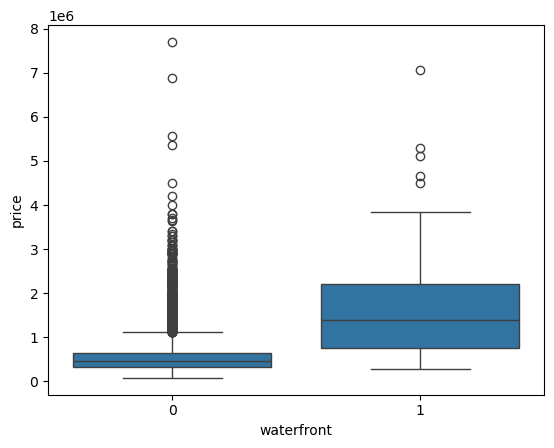

In [42]:
# visualize price vs waterfront

sns.boxplot(x="waterfront", y="price", data=df)
plt.show()

## Regression plot sqft_above vs price

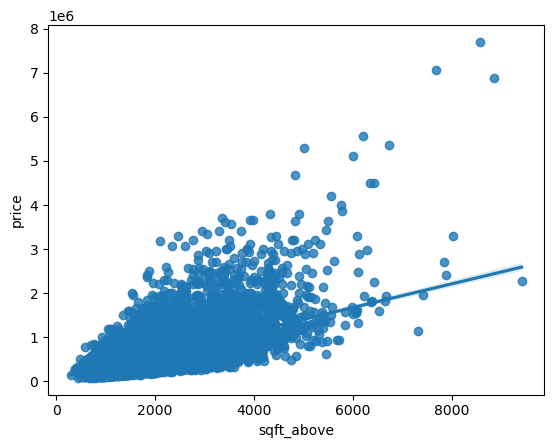

In [43]:
# relationship between sqft_above and price

sns.regplot(x="sqft_above", y="price", data=df)
plt.show()

## Define Features and Targets

In [44]:
# define features used for prediction

features = ["floors","waterfront","lat","bedrooms",
            "sqft_basement","view","bathrooms",
            "sqft_living15","sqft_above","grade","sqft_living"]

X = df[features]
Y = df['price']

## Linear Regression model

In [48]:
# create linear regression model

lm = LinearRegression()
# train model
lm.fit(X,Y)
# check accuracy
print("R² Score:", lm.score(X,Y))

R² Score: 0.6576951666037502


## Train Test Split

In [49]:
# split dataset for training and testing

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.15, random_state=1
)

##  ridge regression model

In [50]:
# ridge regression model

RidgeModel = Ridge(alpha=0.1)

RidgeModel.fit(x_train, y_train)

print("Ridge Test Score:", RidgeModel.score(x_test, y_test))

Ridge Test Score: 0.6478759163939098


## Pipeline Model

In [51]:
# pipeline with scaling + polynomial features

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

pipe.fit(X,Y)

print("Pipeline Score:", pipe.score(X,Y))

Pipeline Score: 0.7513408515988733


## House Price Prediction

In [53]:
# predict price of a sample house

sample_house = pd.DataFrame(
    [[2,0,47.5,3,0,0,2,1800,1200,7,1800]],
    columns=["floors","waterfront","lat","bedrooms",
             "sqft_basement","view","bathrooms",
             "sqft_living15","sqft_above","grade","sqft_living"]
)

predicted_price = lm.predict(sample_house)

print("Predicted House Price:", predicted_price)

Predicted House Price: [326772.78436048]
